# Omics Explorer
**NOD BC2 2026 — Week 2 Project**

A minimal Python tool for loading, describing, interpreting, and quality-checking any omics data file.

---

## How to use this notebook

1. Set `FILE_PATH` in the **Configuration** cell below
2. Run all cells top to bottom (`Cell → Run All`)
3. Read the printed summaries and inspect the plots
4. Find the saved data dictionary at `starnet_data_dictionary.json`

---

## Function map

| # | Function | Input | Output | What it does |
|---|----------|-------|--------|--------------|
| 1 | `load_data(file_path)` | file path string | DataFrame | Reads CSV or Excel into a pandas table |
| 2 | `describe_columns(df)` | DataFrame | `data_dict` | Computes stats for every column (missing values, range, mean, std, skew) |
| 3 | `interpret_columns(df, data_dict)` | DataFrame + data_dict | data_dict (enriched) | Labels each column: protein, metadata, unknown |
| 4 | `detect_warnings(df, data_dict)` | DataFrame + data_dict | warnings list | Scans for 7 types of quality issues and flags them |
| 5 | `plot_distributions(df, data_dict)` | DataFrame + data_dict | figures | Plots distributions for metadata and protein columns |

**Key design rule:** `data_dict` is created once by `describe_columns` and then passed into every subsequent function. Each function adds fields to it — they never overwrite each other. At the end it is saved as a JSON file.

---

## Warning flags reference

| Flag | Trigger | Severity | Why it matters |
|------|---------|----------|----------------|
| `HIGH_MISSINGNESS` | > 20% missing values | HIGH | Column may need exclusion |
| `MODERATE_MISSINGNESS` | 5–20% missing values | MEDIUM | May need imputation |
| `EXTREME_OUTLIER` | Any value > 4 SD from mean | HIGH | Possible batch effect or error |
| `LOW_VARIANCE` | SD < 0.01 | MEDIUM | Column carries no information |
| `HIGH_SKEWNESS` | \|skewness\| > 2 | LOW | May benefit from log-transform |
| `SUSPECTED_LOD_FLOOR` | > 30% of values are identical | MEDIUM | Olink LOD imputation artifact |
| `DUPLICATE_ROWS` | Any identical rows in the file | HIGH | Possible data loading error |

## Imports

Standard scientific Python libraries. Install any missing ones with `pip install <name>`.

In [1]:
import base64          # embedding plots in HTML
import webbrowser      # auto-open report in browser
import pandas as pd       # tables and data manipulation
import numpy as np        # numerical operations
import matplotlib.pyplot as plt  # plotting
import json               # saving the data dictionary
import os                 # file path utilities
from collections import Counter  # counting warning severities

# Make plots appear inline in the notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

**Change `FILE_PATH` to point to your data file. Everything else runs automatically.**

Supported formats: `.csv`, `.xlsx`, `.xls`

In [2]:
# ============================================================
# SET YOUR FILE PATH HERE — change this line, everything runs
# ============================================================
FILE_PATH = "/Users/villedurietz/Desktop/Ville_PhD_Workspace/02_BEAT_IT/context/Villes Work /BEAT_IT_Analysis/train_data_assays_ville.csv"

# How many individual protein distributions to show in Figure 3
# (with 1000+ proteins we can't plot all — increase this if you want more)
N_PROTEIN_SAMPLE = 20

---

## Function 1 — `load_data(file_path)`

**What it does:** Reads a CSV or Excel file from disk into a pandas DataFrame.

A **DataFrame** is pandas' version of a spreadsheet table — rows are samples, columns are variables. Every function below works on this DataFrame.

**Why it's a function (not just one line):**
Later versions will need to load from AWS S3, not just local files. Wrapping the logic in a function means we only change this one place when we add that — everything else stays the same.

```
load_data(file_path)
  ├── detects file extension (.csv vs .xlsx)
  ├── reads the file into a DataFrame
  ├── prints shape (rows × columns) as a sanity check
  └── returns the DataFrame
```

In [3]:
def load_data(file_path):
    """
    Load a CSV or Excel file into a pandas DataFrame.

    Parameters
    ----------
    file_path : str
        Path to the data file (.csv, .xlsx, or .xls)

    Returns
    -------
    pd.DataFrame
        The loaded data (rows = samples, columns = variables)
    """
    ext = os.path.splitext(file_path)[1].lower()  # get the file extension

    if ext == ".csv":
        df = pd.read_csv(file_path)
    elif ext in (".xlsx", ".xls"):
        df = pd.read_excel(file_path)
    else:
        raise ValueError(f"Unsupported file type: '{ext}'. Use .csv or .xlsx")

    print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"File:   {os.path.basename(file_path)}")
    return df

In [4]:
# Run load_data and preview the first 3 rows
df = load_data(FILE_PATH)
df.head(3)

Loaded: 532 rows x 1010 columns
File:   train_data_assays_ville.csv


,starnet_id,4E-BP1,5'-NT,ABL1,ACAN,ACE2,ACP6,ADA,ADAM 22,ADAM 23,...,hOSCAR,sFRP-3,t-PA,uPA,uPA.1,vWF,case,year,Age,Sex_01
0,744,10.73283,10.35205,8.06065,3.41352,3.74183,5.09759,5.42697,4.70241,3.98940,...,10.51664,4.22955,7.04819,4.94122,4.94122,7.88625,1,19,78.0,1.0
1,960,11.67890,11.12228,8.95991,3.80909,4.11034,7.15625,6.77964,4.87222,5.04261,...,10.80918,4.48464,8.03218,7.33065,7.33065,7.83704,1,19,64.0,1.0
2,c287,11.24206,10.12839,8.08709,3.19346,4.32982,5.48298,5.59373,4.58710,5.30954,...,10.87163,4.12577,6.87023,5.27372,5.27372,7.66767,0,19,70.0,1.0


---

## Function 2 — `describe_columns(df)`

**What it does:** Loops through every column and computes a set of statistics. Stores everything in `data_dict` — a Python dictionary keyed by column name.

**Why a dictionary (not a list)?**
With a dict you can look up any column instantly: `data_dict["FKBP1B"]`.
With a list you'd have to loop through every entry to find it — slow and clunky at 1000+ columns.
The dict is also directly saveable as JSON, which becomes our SQL schema reference.

**What gets recorded per column:**

| Field | Meaning |
|-------|---------|
| `dtype` | Data type (float64, int64, object) |
| `n_missing` | Number of missing values (NaN) |
| `pct_missing` | Percentage missing |
| `n_unique` | Number of distinct values |
| `min / max` | Range (numeric columns only) |
| `mean / std` | Average and spread (numeric only) |
| `skew` | Asymmetry of distribution (0 = symmetric) |
| `column_type` | Filled in by `interpret_columns` later |
| `description` | Filled in by `interpret_columns` later |
| `platform` | Filled in by `interpret_columns` later |
| `warnings` | Filled in by `detect_warnings` later |

In [5]:
def describe_columns(df):
    """
    Compute per-column statistics and store in a dictionary.

    This creates the 'data_dict' that all later functions read and write to.
    Fields for column_type, description, platform, and warnings are created
    as None/empty here — they are filled in by the functions that follow.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    dict
        Keys = column names. Values = dict of stats and placeholder fields.
    """
    data_dict = {}

    for col in df.columns:
        is_numeric = pd.api.types.is_numeric_dtype(df[col])

        data_dict[col] = {
            # Basic stats — computed now
            "dtype":       str(df[col].dtype),
            "n_missing":   int(df[col].isna().sum()),
            "pct_missing": round(df[col].isna().mean() * 100, 2),
            "n_unique":    int(df[col].nunique()),
            "min":         round(float(df[col].min()), 4)  if is_numeric else None,
            "max":         round(float(df[col].max()), 4)  if is_numeric else None,
            "mean":        round(float(df[col].mean()), 4) if is_numeric else None,
            "std":         round(float(df[col].std()), 4)  if is_numeric else None,
            "skew":        round(float(df[col].skew()), 4) if is_numeric else None,
            # Placeholders — filled in by later functions
            "column_type": None,
            "description": None,
            "platform":    None,
            "warnings":    [],
        }

    print(f"Described {len(data_dict)} columns.")
    return data_dict

In [6]:
# Run describe_columns and preview the first 5 entries
data_dict = describe_columns(df)

print("\nPreview — first 5 columns:")
for col in list(data_dict.keys())[:5]:
    print(f"\n  {col}")
    for k, v in data_dict[col].items():
        print(f"    {k}: {v}")

Described 1010 columns.

Preview — first 5 columns:

  starnet_id
    dtype: str
    n_missing: 0
    pct_missing: 0.0
    n_unique: 532
    min: None
    max: None
    mean: None
    std: None
    skew: None
    column_type: None
    description: None
    platform: None
    warnings: []

  4E-BP1
    dtype: float64
    n_missing: 0
    pct_missing: 0.0
    n_unique: 532
    min: 4.9511
    max: 12.4748
    mean: 10.5484
    std: 1.2481
    skew: -1.9451
    column_type: None
    description: None
    platform: None
    warnings: []

  5'-NT
    dtype: float64
    n_missing: 0
    pct_missing: 0.0
    n_unique: 532
    min: 9.1514
    max: 13.2414
    mean: 11.0102
    std: 0.7503
    skew: 0.6532
    column_type: None
    description: None
    platform: None
    warnings: []

  ABL1
    dtype: float64
    n_missing: 0
    pct_missing: 0.0
    n_unique: 530
    min: 1.3434
    max: 11.545
    mean: 7.3853
    std: 1.973
    skew: -0.9168
    column_type: None
    description: None
    

---

## Function 3 — `interpret_columns(df, data_dict)`

**What it does:** Labels each column with a `column_type` and a plain-English `description`. Uses rule-based detection — no API call needed.

**Detection priority (tries each rule in order, stops at first match):**

1. **STARNET-specific known columns** — exact name match against a hardcoded lookup table (`starnet_id`, `case`, `year`, `Sex_01`, `Age`)
2. **Generic metadata keywords** — column name contains words like `id`, `age`, `sex`, `batch`, `plate`, `qc`, etc.
3. **Olink NPX range check** — float column with values in roughly -15 to +25 range → `protein_npx` + `Olink Target96` platform
4. **Low-cardinality integer** — ≤10 unique values → `categorical_metadata`
5. **Fallback** → `unknown` (requires manual review)

**Column types assigned:**

| Type | Meaning |
|------|---------|
| `sample_metadata` | Clinical / demographic variable (age, sex, case status) |
| `protein_npx` | Olink proteomics measurement in NPX (log2-normalised) |
| `categorical_metadata` | Categorical variable with few levels |
| `unknown` | Could not determine — flag for manual review |

In [7]:
# ── User overrides ────────────────────────────────────────────────────────────
# If interpret_columns misclassifies a column, add it here.
# Format: { "exact_column_name": "correct_column_type" }
# Valid types: "protein_npx", "sample_metadata", "categorical_metadata", "unknown"
OVERRIDES = {
    # Example: "uPA": "protein_npx"
}

# ── STARNET-specific known columns ────────────────────────────────────────────
STARNET_META = {
    "starnet_id": (
        "sample_metadata",
        "STARNET patient identifier — unique ID linking plasma sample to patient record"
    ),
    "case": (
        "sample_metadata",
        "Disease status: 1 = obstructive CAD confirmed by coronary angiography, 0 = control"
    ),
    "year": (
        "sample_metadata",
        "Sample collection year: 2018 (controls only) or 2019 (cases + controls)"
    ),
    "Sex_01": (
        "sample_metadata",
        "Biological sex: 0 = female, 1 = male"
    ),
    "Age": (
        "sample_metadata",
        "Patient age at time of blood sampling (years)"
    ),
}

# ── Generic metadata keywords (whole-word match against column name tokens) ───
# Only applied to non-numeric columns — numeric columns go through NPX check first.
META_KEYWORDS = [
    "id", "sample", "patient", "subject", "age", "sex", "gender",
    "date", "batch", "plate", "qc", "flag", "group", "label", "status",
    "year", "time", "visit", "cohort", "index"
]


def interpret_columns(df, data_dict):
    """
    Label each column with a type and description using rule-based detection.

    Modifies data_dict in-place (adds 'column_type', 'description', 'platform').

    Detection priority (evaluated in order, stops at first match):
      0. User OVERRIDES dict — always wins
      1. STARNET known columns — exact name match
      2. Olink NPX range check — numeric columns in [-15, 25] → protein_npx
         (runs BEFORE keyword check to prevent protein misclassification)
      3. Generic metadata keywords — substring match on non-numeric columns
      4. Low-cardinality integer — ≤10 unique values → categorical_metadata
      5. Fallback → unknown

    Parameters
    ----------
    df : pd.DataFrame
    data_dict : dict  (from describe_columns)

    Returns
    -------
    dict
        Updated data_dict with column_type, description, platform filled in
    """
    for col in df.columns:
        info = data_dict[col]
        col_lower = col.lower()

        # ── Priority 0: user overrides ─────────────────────────────────────────
        if col in OVERRIDES:
            override_type = OVERRIDES[col]
            data_dict[col]["column_type"] = override_type
            data_dict[col]["description"] = f"User-overridden type: {override_type}"
            data_dict[col]["platform"]    = "manual override"
            continue

        # ── Priority 1: STARNET known columns ─────────────────────────────────
        if col in STARNET_META:
            col_type, desc = STARNET_META[col]
            data_dict[col]["column_type"] = col_type
            data_dict[col]["description"] = desc
            data_dict[col]["platform"]    = "STARNET cohort metadata"
            continue

        # ── Priority 2: Olink NPX range check (numeric columns only) ──────────
        # Intentionally runs BEFORE keyword check: protein names like "uPA", "t-PA",
        # "TIMP-1" etc. can contain metadata keywords as substrings — checking the
        # numeric range first prevents misclassification.
        if info["dtype"] in ("float64", "float32") and info["min"] is not None:
            if -15 <= info["min"] and info["max"] <= 25:
                data_dict[col]["column_type"] = "protein_npx"
                data_dict[col]["description"] = (
                    f"Olink proximity extension assay (PEA) protein measurement. "
                    f"Values in NPX (Normalized Protein eXpression), log2-scale. "
                    f"Range in this file: {info['min']} to {info['max']}."
                )
                data_dict[col]["platform"] = "Olink Target96"
                continue

        # ── Priority 3: generic metadata keywords (non-numeric only) ──────────
        if any(kw in col_lower for kw in META_KEYWORDS):
            data_dict[col]["column_type"] = "sample_metadata"
            data_dict[col]["description"] = f"Metadata column (keyword detected in name: '{col}')"
            data_dict[col]["platform"]    = "cohort metadata"
            continue

        # ── Priority 4: low-cardinality integer → categorical ──────────────────
        if info["n_unique"] <= 10 and info["dtype"] in ("int64", "float64"):
            data_dict[col]["column_type"] = "categorical_metadata"
            data_dict[col]["description"] = (
                f"Categorical column with {info['n_unique']} unique values: "
                f"{sorted(df[col].dropna().unique().tolist())}"
            )
            data_dict[col]["platform"] = None
            continue

        # ── Fallback ───────────────────────────────────────────────────────────
        data_dict[col]["column_type"] = "unknown"
        data_dict[col]["description"] = "Could not determine type — review manually"
        data_dict[col]["platform"]    = None

    # Summary
    from collections import Counter
    type_counts = Counter(data_dict[c]["column_type"] for c in data_dict)
    print("Column interpretation complete:")
    for col_type, count in type_counts.most_common():
        print(f"  {col_type}: {count}")
    if OVERRIDES:
        print(f"  (OVERRIDES applied: {list(OVERRIDES.keys())})")

    return data_dict


In [8]:
# Run interpret_columns — updates data_dict in place
data_dict = interpret_columns(df, data_dict)

# Preview: show interpretation for the first 5 columns
print("\nPreview — column interpretations:")
for col in list(data_dict.keys())[:8]:
    print(f"  {col:15s} | {data_dict[col]['column_type']:20s} | {data_dict[col]['platform']}")

Column interpretation complete:
  protein_npx: 1005
  sample_metadata: 5

Preview — column interpretations:
  starnet_id      | sample_metadata      | STARNET cohort metadata
  4E-BP1          | protein_npx          | Olink Target96
  5'-NT           | protein_npx          | Olink Target96
  ABL1            | protein_npx          | Olink Target96
  ACAN            | protein_npx          | Olink Target96
  ACE2            | protein_npx          | Olink Target96
  ACP6            | protein_npx          | Olink Target96
  ADA             | protein_npx          | Olink Target96


---

## Function 4 — `detect_warnings(df, data_dict)`

**What it does:** Scans every column for 7 types of quality issues. Each issue is recorded as a warning with a severity level.

**Why these specific flags?**

- `HIGH_MISSINGNESS` / `MODERATE_MISSINGNESS` — missing data affects every downstream analysis. >20% is generally a hard exclusion threshold in proteomics.
- `EXTREME_OUTLIER` — values > 4 standard deviations from the mean are unlikely to be biological. Common causes: batch effects, pipetting errors, failed assays.
- `LOW_VARIANCE` — a protein that barely varies across 500+ patients carries no useful signal for case/control discrimination.
- `HIGH_SKEWNESS` — many statistical models assume roughly symmetric distributions. Highly skewed data may need log-transformation before modelling.
- `SUSPECTED_LOD_FLOOR` — Olink-specific. When a protein's signal falls below the limit of detection (LOD), Olink imputes a fixed floor value. If >30% of samples share one identical value, the protein is probably hitting that floor — it is unreliable as a biomarker.
- `DUPLICATE_ROWS` — identical rows should not exist in a properly curated dataset. This flags data loading or merging errors.

Warnings are stored **both** in `data_dict[col]['warnings']` (for the JSON export) and returned as a flat list (for printing and filtering).

In [9]:
def detect_warnings(df, data_dict):
    """
    Scan every column for quality issues and record warning flags.

    Warnings are stored in data_dict[col]['warnings'] (list of dicts)
    and also returned as a flat list for easy printing and filtering.

    Parameters
    ----------
    df : pd.DataFrame
    data_dict : dict  (from interpret_columns)

    Returns
    -------
    list of dict
        Each entry: {column, flag, severity, detail}
    """
    all_warnings = []

    for col in df.columns:
        info = data_dict[col]
        col_warnings = []

        # ── Missing values ─────────────────────────────────────────────────────
        if info["pct_missing"] > 20:
            col_warnings.append({
                "column":   col,
                "flag":     "HIGH_MISSINGNESS",
                "severity": "HIGH",
                "detail":   f"{info['pct_missing']}% of values are missing"
            })
        elif info["pct_missing"] > 5:
            col_warnings.append({
                "column":   col,
                "flag":     "MODERATE_MISSINGNESS",
                "severity": "MEDIUM",
                "detail":   f"{info['pct_missing']}% of values are missing"
            })

        # Numeric-only checks
        if info["std"] is not None:
            series = df[col].dropna()

            # ── Extreme outliers (> 4 SD) ──────────────────────────────────────
            if info["std"] > 0:
                max_z = ((series - series.mean()) / series.std()).abs().max()
                if max_z > 4:
                    col_warnings.append({
                        "column":   col,
                        "flag":     "EXTREME_OUTLIER",
                        "severity": "HIGH",
                        "detail":   f"Max z-score = {max_z:.1f} (threshold: 4.0)"
                    })

            # ── Low variance ───────────────────────────────────────────────────
            if info["std"] < 0.01:
                col_warnings.append({
                    "column":   col,
                    "flag":     "LOW_VARIANCE",
                    "severity": "MEDIUM",
                    "detail":   f"SD = {info['std']} — column may carry no biological information"
                })

            # ── High skewness ──────────────────────────────────────────────────
            if info["skew"] is not None and abs(info["skew"]) > 2:
                col_warnings.append({
                    "column":   col,
                    "flag":     "HIGH_SKEWNESS",
                    "severity": "LOW",
                    "detail":   f"Skewness = {info['skew']:.2f} — consider log-transformation"
                })

            # ── Suspected LOD floor (Olink-specific artifact) ──────────────────
            if info["column_type"] == "protein_npx" and len(series) > 0:
                top_freq = series.value_counts(normalize=True).iloc[0]
                top_val  = series.value_counts().index[0]
                if top_freq > 0.30:
                    col_warnings.append({
                        "column":   col,
                        "flag":     "SUSPECTED_LOD_FLOOR",
                        "severity": "MEDIUM",
                        "detail":   (
                            f"{top_freq*100:.1f}% of values = {top_val:.3f} "
                            f"— likely Olink limit-of-detection imputation"
                        )
                    })

        # Store warnings in data_dict and accumulate in flat list
        data_dict[col]["warnings"] = col_warnings
        all_warnings.extend(col_warnings)

    # ── Duplicate rows (whole dataframe) ──────────────────────────────────────
    n_dupes = df.duplicated().sum()
    if n_dupes > 0:
        all_warnings.append({
            "column":   "DATAFRAME",
            "flag":     "DUPLICATE_ROWS",
            "severity": "HIGH",
            "detail":   f"{n_dupes} duplicate rows — possible data loading error"
        })

    # Summary
    severity_counts = Counter(w["severity"] for w in all_warnings)
    print("Warning scan complete:")
    print(f"  HIGH:   {severity_counts.get('HIGH', 0)} flags")
    print(f"  MEDIUM: {severity_counts.get('MEDIUM', 0)} flags")
    print(f"  LOW:    {severity_counts.get('LOW', 0)} flags")
    print(f"  Total columns flagged: {len(set(w['column'] for w in all_warnings))}")

    return all_warnings

In [10]:
# Run detect_warnings
warnings = detect_warnings(df, data_dict)

# Print warnings grouped by severity
for severity in ["HIGH", "MEDIUM", "LOW"]:
    flagged = [w for w in warnings if w["severity"] == severity]
    if flagged:
        print(f"\n=== {severity} ({len(flagged)} flags) ===")
        for w in flagged[:10]:  # cap at 10 per severity to keep output readable
            print(f"  [{w['flag']}] {w['column']}: {w['detail']}")
        if len(flagged) > 10:
            print(f"  ... and {len(flagged) - 10} more (see data dictionary JSON)")

Warning scan complete:
  HIGH:   461 flags
  MEDIUM: 23 flags
  LOW:    52 flags
  Total columns flagged: 466

=== HIGH (461 flags) ===
  [EXTREME_OUTLIER] 4E-BP1: Max z-score = 4.5 (threshold: 4.0)
  [EXTREME_OUTLIER] ACAN: Max z-score = 5.2 (threshold: 4.0)
  [EXTREME_OUTLIER] ADA: Max z-score = 4.2 (threshold: 4.0)
  [EXTREME_OUTLIER] ADAM 22: Max z-score = 4.2 (threshold: 4.0)
  [EXTREME_OUTLIER] ADAM 23: Max z-score = 4.2 (threshold: 4.0)
  [EXTREME_OUTLIER] ADAM 8: Max z-score = 6.4 (threshold: 4.0)
  [EXTREME_OUTLIER] ADGRE2: Max z-score = 4.5 (threshold: 4.0)
  [EXTREME_OUTLIER] ADGRG1: Max z-score = 5.0 (threshold: 4.0)
  [EXTREME_OUTLIER] AGR2: Max z-score = 4.1 (threshold: 4.0)
  [EXTREME_OUTLIER] AGR3: Max z-score = 5.2 (threshold: 4.0)
  ... and 451 more (see data dictionary JSON)

=== MEDIUM (23 flags) ===
  [SUSPECTED_LOD_FLOOR] CD28: 36.5% of values = 2.263 — likely Olink limit-of-detection imputation
  [SUSPECTED_LOD_FLOOR] CES2: 33.3% of values = 2.152 — likely Olink 

---

## Function 5 — `plot_distributions(df, data_dict, n_protein_sample)`

**What it does:** Produces three figures:

1. **Metadata columns** — one subplot per clinical/demographic variable. Bar chart for categoricals (e.g. case/control), histogram for continuous (e.g. age). Columns with any warning flag get an orange highlight.

2. **Protein overview** — two panels:
   - Combined NPX distribution across all ~1000 proteins (what does the data look like globally?)
   - Missingness per protein (how many proteins are poorly measured?)

3. **Protein sample grid** — individual distributions for `n_protein_sample` proteins. Flagged proteins are shown in red so you can spot problems visually.

All three figures are also saved as PNG files alongside the notebook.

In [11]:
def plot_distributions(df, data_dict, n_protein_sample=20):
    """
    Plot data distributions for metadata and protein columns.

    Produces three figures:
      1. Metadata columns (one subplot each)
      2. Global protein NPX overview + missingness per protein
      3. Sample grid of individual protein distributions

    Flagged columns (any warnings) are highlighted in orange/red.
    All figures are saved as PNG files.

    Parameters
    ----------
    df : pd.DataFrame
    data_dict : dict  (from detect_warnings)
    n_protein_sample : int
        Number of individual protein distributions to show (default 20)
    """
    meta_cols    = [c for c in df.columns if data_dict[c]["column_type"] == "sample_metadata"]
    protein_cols = [c for c in df.columns if data_dict[c]["column_type"] == "protein_npx"]

    print(f"Plotting {len(meta_cols)} metadata columns and {n_protein_sample} of {len(protein_cols)} proteins.")

    # ── Figure 1: Metadata columns ─────────────────────────────────────────────
    if meta_cols:
        fig, axes = plt.subplots(1, len(meta_cols), figsize=(4 * len(meta_cols), 4))
        if len(meta_cols) == 1:
            axes = [axes]  # make it iterable if there is only one column

        for ax, col in zip(axes, meta_cols):
            has_warning = len(data_dict[col]["warnings"]) > 0
            color = "darkorange" if has_warning else "steelblue"

            if df[col].nunique() <= 10:  # categorical
                df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color=color, edgecolor="white")
            else:  # continuous
                df[col].hist(bins=20, ax=ax, color=color, edgecolor="white")

            title = col + (" (WARNING)" if has_warning else "")
            ax.set_title(title, fontsize=10, fontweight="bold")
            ax.set_xlabel("")

        plt.suptitle("Metadata Columns", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.savefig("metadata_distributions.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── Figure 2: Global protein overview ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Panel A: combined NPX distribution across all proteins
    all_npx = df[protein_cols].values.flatten()
    all_npx = all_npx[~np.isnan(all_npx)]
    axes[0].hist(all_npx, bins=80, color="coral", edgecolor="white", alpha=0.85)
    axes[0].set_title(f"All {len(protein_cols)} proteins — combined NPX", fontweight="bold")
    axes[0].set_xlabel("NPX (log2 scale)")
    axes[0].set_ylabel("Count")

    # Panel B: missingness per protein
    pct_missing = [data_dict[c]["pct_missing"] for c in protein_cols]
    axes[1].hist(pct_missing, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[1].set_title("Missingness per protein (%)", fontweight="bold")
    axes[1].set_xlabel("% missing")
    axes[1].set_ylabel("Number of proteins")
    axes[1].axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="5% (MEDIUM threshold)")
    axes[1].axvline(20, color="red",    linestyle="--", linewidth=1.5, label="20% (HIGH threshold)")
    axes[1].legend(fontsize=8)

    plt.suptitle("Protein NPX — Overview", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("protein_overview.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Figure 3: Individual protein sample ────────────────────────────────────
    sample_proteins = protein_cols[:n_protein_sample]
    ncols = 5
    nrows = int(np.ceil(len(sample_proteins) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
    axes = axes.flatten()

    for i, col in enumerate(sample_proteins):
        has_warning = len(data_dict[col]["warnings"]) > 0
        color = "salmon" if has_warning else "coral"
        df[col].hist(bins=30, ax=axes[i], color=color, edgecolor="white")
        title = col + (" *" if has_warning else "")
        axes[i].set_title(title, fontsize=7, fontweight="bold")
        axes[i].tick_params(labelsize=6)

    # Hide any unused subplot panels
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"Protein NPX Distributions — {n_protein_sample} of {len(protein_cols)} shown  (* = flagged)",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("protein_sample_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

Plotting 5 metadata columns and 20 of 1005 proteins.


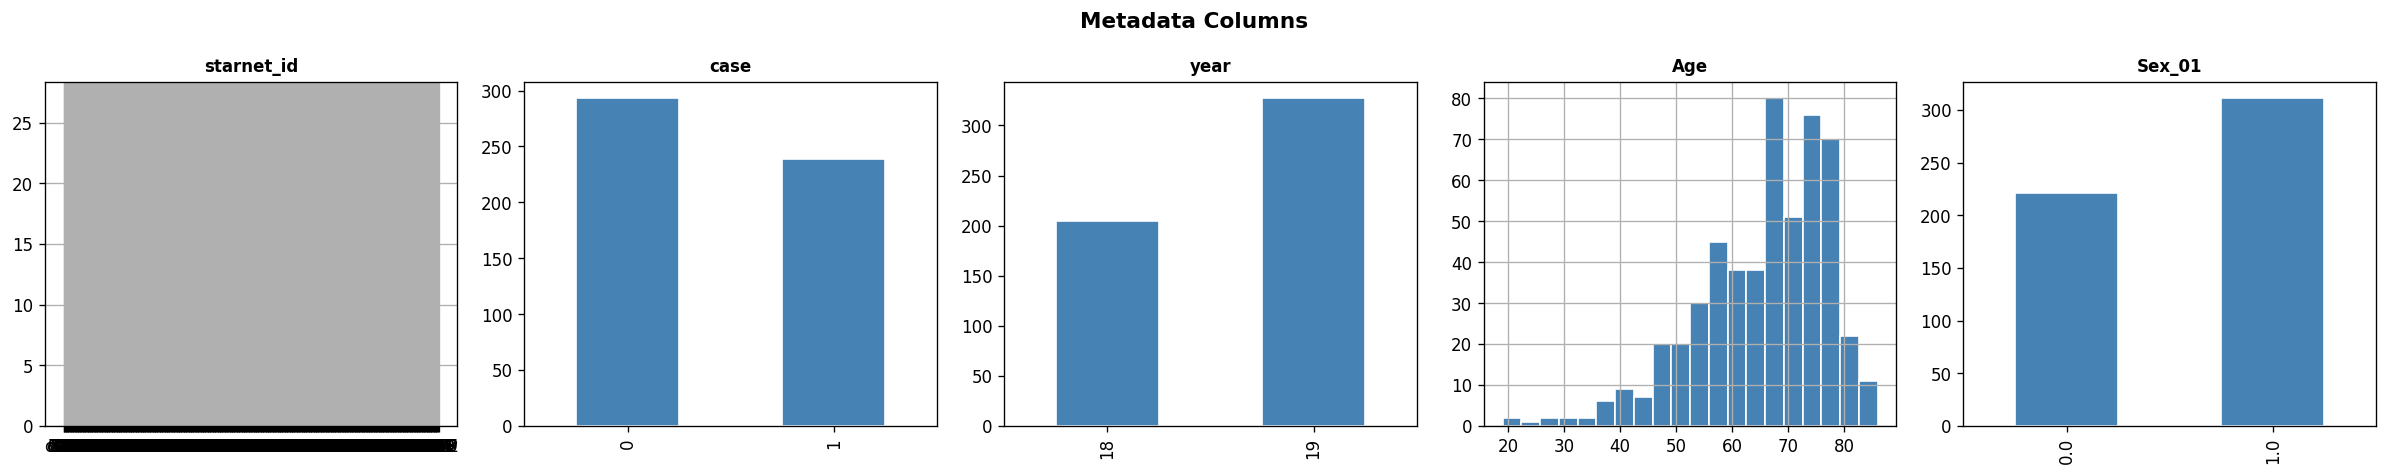

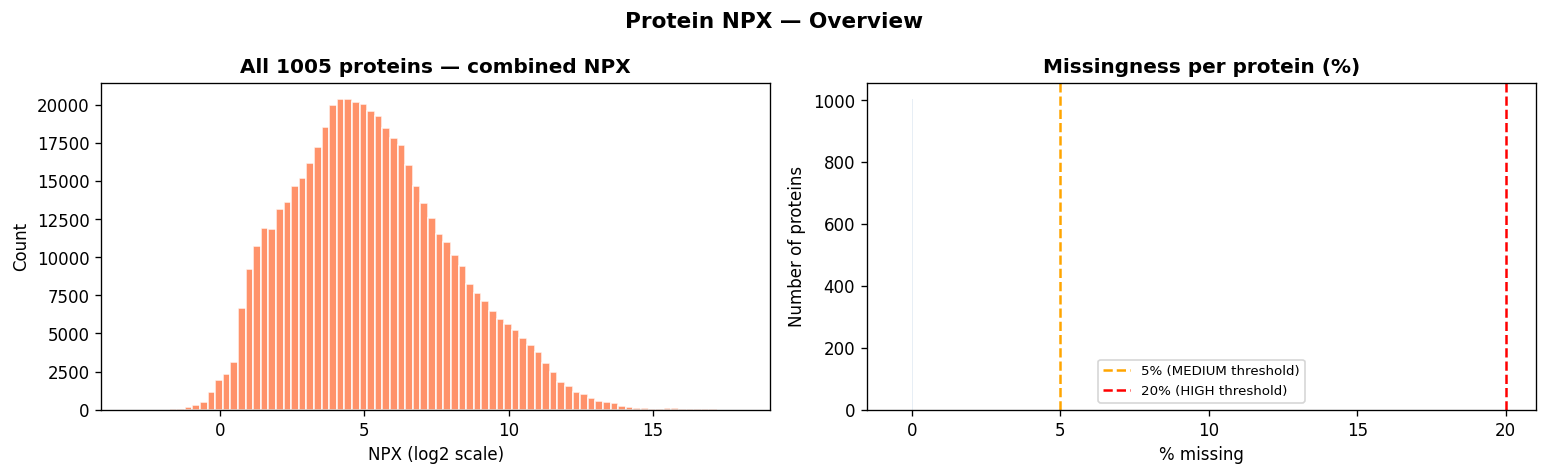

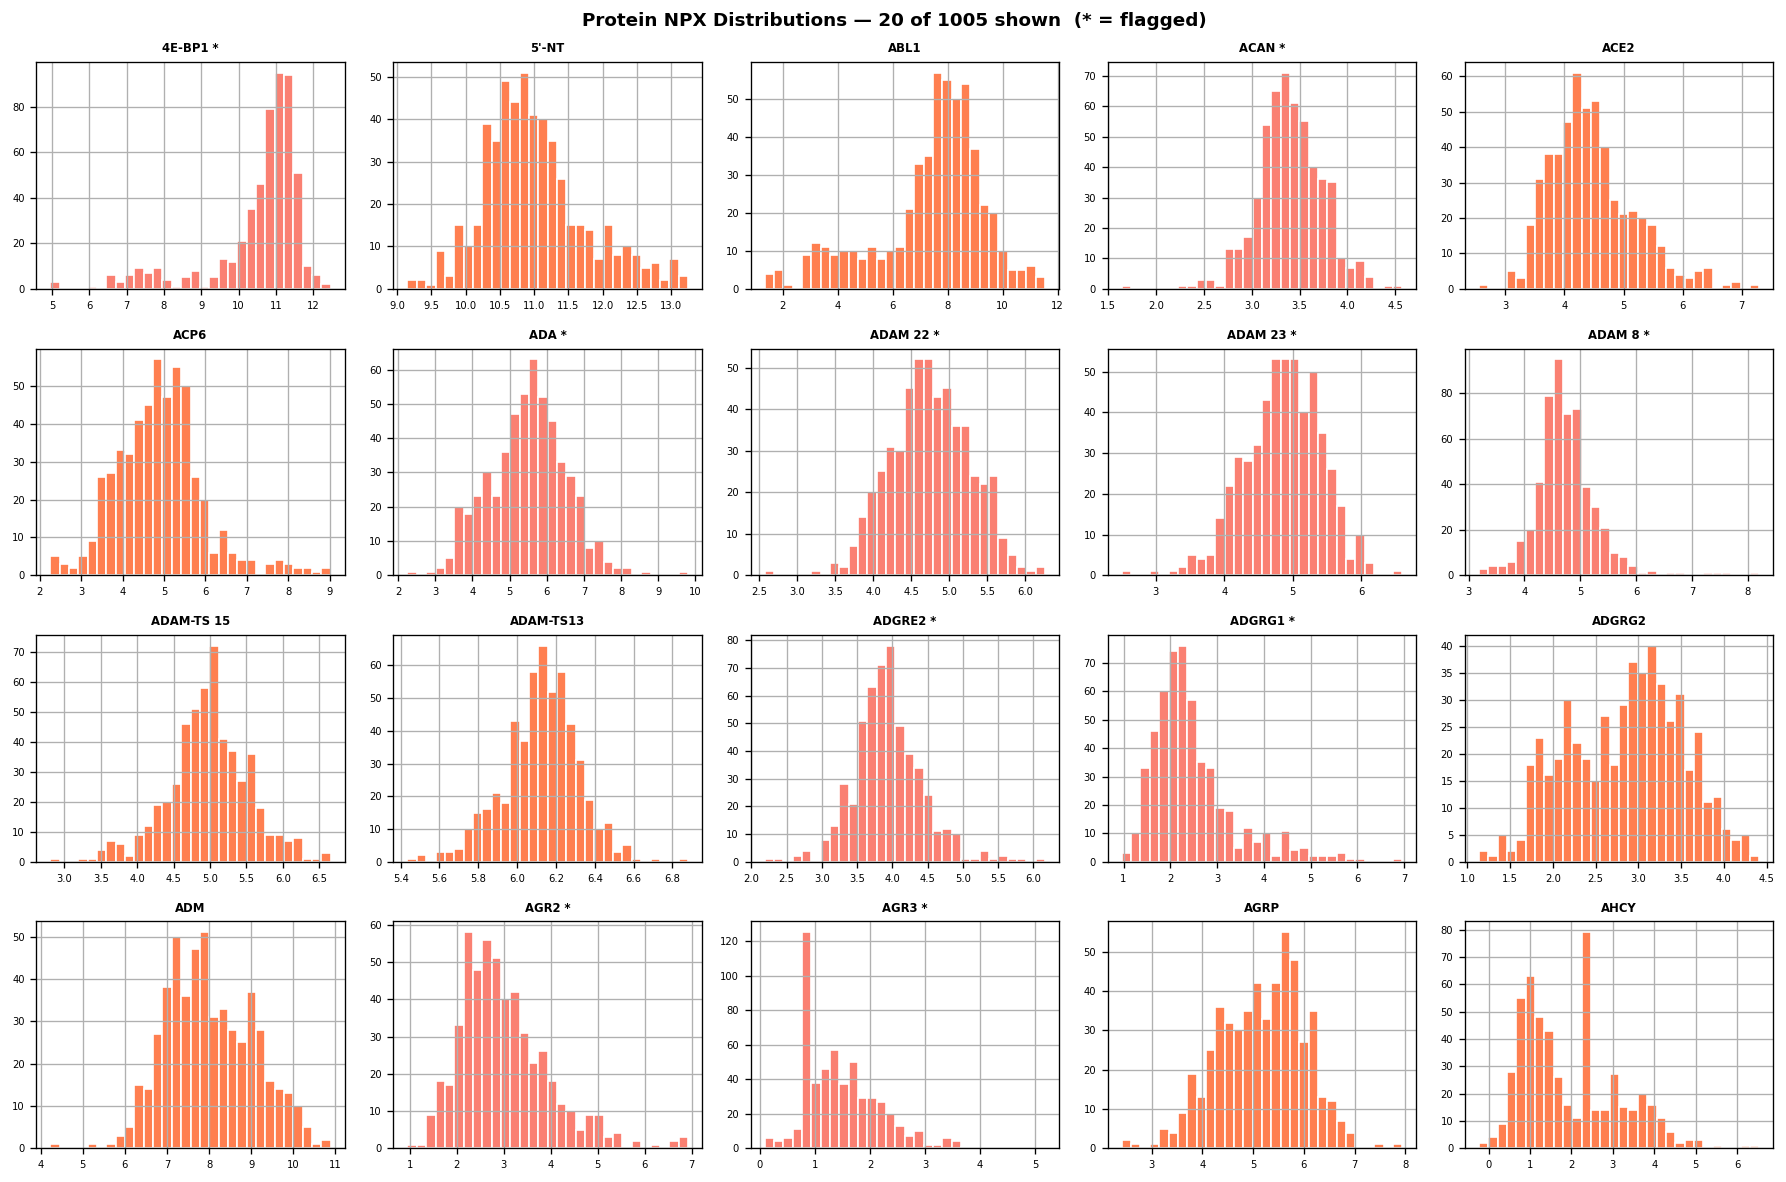

In [12]:
# Run plot_distributions
plot_distributions(df, data_dict, n_protein_sample=N_PROTEIN_SAMPLE)

---

## Save Data Dictionary

Export `data_dict` as a JSON file. This is the structured record of every column in the file — types, stats, descriptions, platform, and all warnings.

**Why JSON?**
- Human-readable (open it in any text editor or VS Code)
- Machine-readable (directly usable by the AWS S3 → SQL schema pipeline in v3)
- Keyed by column name so any column can be looked up instantly

The file is saved next to the notebook as `starnet_data_dictionary.json`.

In [13]:
# Save the complete data dictionary to JSON
output_path = "starnet_data_dictionary.json"

with open(output_path, "w") as f:
    json.dump(data_dict, f, indent=2)

print(f"Saved: {output_path}")
print(f"Contains: {len(data_dict)} columns")
print(f"\nExample entry (first protein column):")

# Show one protein entry as a formatted preview
first_protein = next(c for c in data_dict if data_dict[c]["column_type"] == "protein_npx")
print(json.dumps({first_protein: data_dict[first_protein]}, indent=2))

Saved: starnet_data_dictionary.json
Contains: 1010 columns

Example entry (first protein column):
{
  "4E-BP1": {
    "dtype": "float64",
    "n_missing": 0,
    "pct_missing": 0.0,
    "n_unique": 532,
    "min": 4.9511,
    "max": 12.4748,
    "mean": 10.5484,
    "std": 1.2481,
    "skew": -1.9451,
    "column_type": "protein_npx",
    "description": "Olink proximity extension assay (PEA) protein measurement. Values in NPX (Normalized Protein eXpression), log2-scale. Range in this file: 4.9511 to 12.4748.",
    "platform": "Olink Target96",
    "warnings": [
      {
        "column": "4E-BP1",
        "flag": "EXTREME_OUTLIER",
        "severity": "HIGH",
        "detail": "Max z-score = 4.5 (threshold: 4.0)"
      }
    ]
  }
}


---

## Demo mode — `generate_report(file_path)`

**Run this single cell to execute the full pipeline and open an HTML report in your browser.**

It calls all five functions above in sequence, embeds the plots directly into the HTML (no external files needed), and auto-opens the report. The step-by-step cells above are the teaching structure — this cell is the demo.

Output file: `omics_explorer_report.html` (saved next to the notebook)

In [14]:
def generate_report(file_path, n_protein_sample=20):
    """
    Run the full omics-explorer pipeline and open a self-contained HTML report in the browser.
    """
    import matplotlib
    matplotlib.use("Agg")
    from io import BytesIO
    import matplotlib.pyplot as _plt
    from collections import Counter as _Counter

    # ── Run pipeline ──────────────────────────────────────────────────────────
    df        = load_data(file_path)
    data_dict = describe_columns(df)
    data_dict = interpret_columns(df, data_dict)
    warnings  = detect_warnings(df, data_dict)

    meta_cols    = [c for c in df.columns if data_dict[c]["column_type"] == "sample_metadata"]
    protein_cols = [c for c in df.columns if data_dict[c]["column_type"] == "protein_npx"]

    # ── Plot helpers ──────────────────────────────────────────────────────────
    def fig_to_b64(fig):
        buf = BytesIO()
        fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
        buf.seek(0)
        return base64.b64encode(buf.read()).decode()

    def img_tag(b64, alt=""):
        return '<img src="data:image/png;base64,' + b64 + '" alt="' + alt + '" style="max-width:100%;border-radius:6px;margin:8px 0 16px;">'

    def infobox(text):
        return (
            '<details style="margin:0 0 18px;background:#f0f4ff;border-left:4px solid #4a6fa5;'
            'border-radius:0 6px 6px 0;padding:10px 16px;">'
            '<summary style="cursor:pointer;font-weight:600;color:#4a6fa5;font-size:.88em;'
            'letter-spacing:.02em;">&#9432;&nbsp; What does this mean?</summary>'
            '<p style="margin:10px 0 2px;font-size:.86em;color:#333;line-height:1.6;">' + text + '</p>'
            '</details>'
        )

    # ── Figure 1 — Metadata (multi-row, max 5 per row) ───────────────────────
    MAX_PER_ROW  = 5
    n_meta       = len(meta_cols)
    n_rows_meta  = -(-n_meta // MAX_PER_ROW)
    n_cols_meta  = min(n_meta, MAX_PER_ROW)

    fig1, axes1 = _plt.subplots(
        n_rows_meta, n_cols_meta,
        figsize=(4.5 * n_cols_meta, 4.5 * n_rows_meta),
        squeeze=False
    )
    for idx, col in enumerate(meta_cols):
        row, cidx = divmod(idx, MAX_PER_ROW)
        ax    = axes1[row][cidx]
        color = "darkorange" if data_dict[col]["warnings"] else "steelblue"
        if df[col].nunique() <= 10:
            df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color=color, edgecolor="white")
            ax.tick_params(axis="x", rotation=30, labelsize=8)
        else:
            df[col].hist(bins=20, ax=ax, color=color, edgecolor="white")
        label = col + (" \u26a0" if data_dict[col]["warnings"] else "")
        ax.set_title(label, fontsize=9, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Count", fontsize=8)
    for idx in range(n_meta, n_rows_meta * n_cols_meta):
        row, cidx = divmod(idx, MAX_PER_ROW)
        axes1[row][cidx].set_visible(False)
    _plt.suptitle("Metadata Columns", fontsize=13, fontweight="bold", y=1.02)
    _plt.tight_layout()
    b64_meta = fig_to_b64(fig1)
    _plt.close(fig1)

    # ── Figure 2 — Protein overview ───────────────────────────────────────────
    fig2, axes2 = _plt.subplots(1, 2, figsize=(16, 5))

    all_npx = df[protein_cols].values.flatten()
    all_npx = all_npx[~np.isnan(all_npx)]
    axes2[0].hist(all_npx, bins=80, color="coral", edgecolor="white", alpha=0.85)
    axes2[0].set_title(
        "All " + str(len(protein_cols)) + " proteins — combined NPX distribution",
        fontweight="bold", fontsize=12
    )
    axes2[0].set_xlabel("NPX (log2 Normalized Protein eXpression)", fontsize=10)
    axes2[0].set_ylabel("Count (observations across all proteins)", fontsize=10)
    axes2[0].axvline(float(all_npx.mean()), color="#555", linestyle="--", linewidth=1.2,
                     label="Mean = " + str(round(float(all_npx.mean()), 1)))
    axes2[0].legend(fontsize=9)

    pct_missing = [data_dict[c]["pct_missing"] for c in protein_cols]
    axes2[1].hist(pct_missing, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes2[1].set_title("Missingness per protein", fontweight="bold", fontsize=12)
    axes2[1].set_xlabel("% of samples with missing value for that protein", fontsize=10)
    axes2[1].set_ylabel("Number of proteins", fontsize=10)
    axes2[1].axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="5% — MEDIUM threshold")
    axes2[1].axvline(20, color="red",    linestyle="--", linewidth=1.5, label="20% — HIGH threshold")
    axes2[1].legend(fontsize=9)

    _plt.suptitle("Protein NPX Quality Overview", fontsize=14, fontweight="bold")
    _plt.tight_layout()
    b64_protein_overview = fig_to_b64(fig2)
    _plt.close(fig2)

    # ── Figure 3 — Individual protein sample grid ─────────────────────────────
    sample_proteins = protein_cols[:n_protein_sample]
    ncols3 = 5
    nrows3 = -(-len(sample_proteins) // ncols3)
    fig3, axes3 = _plt.subplots(nrows3, ncols3, figsize=(ncols3 * 3.2, nrows3 * 2.8))
    axes3 = axes3.flatten()
    for i, col in enumerate(sample_proteins):
        color = "salmon" if data_dict[col]["warnings"] else "coral"
        df[col].hist(bins=30, ax=axes3[i], color=color, edgecolor="white")
        label = col + (" *" if data_dict[col]["warnings"] else "")
        axes3[i].set_title(label, fontsize=7.5, fontweight="bold")
        axes3[i].tick_params(labelsize=6)
        axes3[i].set_xlabel("NPX", fontsize=6)
    for j in range(i + 1, len(axes3)):
        axes3[j].set_visible(False)
    _plt.suptitle(
        "Individual Protein Distributions — " + str(n_protein_sample) +
        " of " + str(len(protein_cols)) + " shown  (* = flagged)",
        fontsize=11, fontweight="bold"
    )
    _plt.tight_layout()
    b64_protein_grid = fig_to_b64(fig3)
    _plt.close(fig3)

    # ── Summary stats ─────────────────────────────────────────────────────────
    type_counts = _Counter(data_dict[c]["column_type"] for c in data_dict)
    sev_counts  = _Counter(w["severity"] for w in warnings)

    # ── Warning table ─────────────────────────────────────────────────────────
    ROWBG  = {"HIGH": "#ffe0e0", "MEDIUM": "#fff8e1", "LOW": "#e8f4fd"}
    BADGEC = {"HIGH": "#c0392b", "MEDIUM": "#856404", "LOW": "#1a5276"}
    warning_rows = ""
    for w in warnings:
        bg  = ROWBG.get(w["severity"], "#fff")
        col = BADGEC.get(w["severity"], "#333")
        warning_rows += (
            '<tr style="background:' + bg + '">'
            '<td><span style="color:' + col + ';font-weight:700">' + w["severity"] + '</span></td>'
            '<td><code>' + w["flag"] + '</code></td>'
            '<td style="font-family:monospace;font-size:.82em">' + w["column"] + '</td>'
            '<td>' + w["detail"] + '</td></tr>'
        )

    # ── Summary cards ─────────────────────────────────────────────────────────
    cards_data = [
        (df.shape[0],                         "Samples",           "#2c3e50"),
        (df.shape[1],                         "Total columns",     "#2c3e50"),
        (type_counts.get("protein_npx", 0),   "Proteins (NPX)",    "#27ae60"),
        (type_counts.get("sample_metadata",0),"Metadata columns",  "#2980b9"),
        (sev_counts.get("HIGH",   0),         "HIGH warnings",     "#c0392b"),
        (sev_counts.get("MEDIUM", 0),         "MEDIUM warnings",   "#e67e22"),
        (sev_counts.get("LOW",    0),         "LOW warnings",      "#2980b9"),
    ]
    cards_html = "".join(
        '<div class="card"><div class="val" style="color:' + c[2] + '">' + str(c[0]) + '</div>'
        '<div class="lbl">' + c[1] + '</div></div>'
        for c in cards_data
    )

    # ── Info box text ─────────────────────────────────────────────────────────
    info_summary = (
        "The summary cards give you a quick overview of your dataset before looking at any details. "
        "<b>Samples</b> = number of participants (rows in the file). "
        "<b>Total columns</b> = every variable in the file. "
        "<b>Proteins (NPX)</b> = columns automatically identified as Olink protein measurements. "
        "<b>Metadata columns</b> = clinical or demographic variables (age, sex, diagnosis, etc.). "
        "The warning counts tell you how many quality issues were found: "
        "<b>HIGH</b> = needs attention before analysis, "
        "<b>MEDIUM</b> = may need imputation or flagging, "
        "<b>LOW</b> = informational."
    )
    info_meta = (
        "Each plot shows the distribution of one metadata (non-protein) column across all participants. "
        "<b>Bar charts</b> are used for categorical variables (e.g. case/control, sex, year collected). "
        "<b>Histograms</b> are used for continuous variables (e.g. age). "
        "An <b>orange column</b> means a quality warning was detected. "
        "For this STARNET file: "
        "<code>case</code> = disease status (1 = obstructive CAD confirmed by coronary angiography, 0 = control); "
        "<code>year</code> = collection year (2018 = controls only, 2019 = cases + controls); "
        "<code>Sex_01</code> = biological sex (0 = female, 1 = male); "
        "<code>Age</code> = age at blood draw (years)."
    )
    info_protein_overview = (
        "<b>Left panel — combined NPX distribution:</b> All " + str(len(protein_cols)) + " proteins "
        "stacked into one histogram. NPX (Normalized Protein eXpression) is Olink's measurement unit. "
        "It is log2-normalised: a difference of 1 NPX = 2x difference in protein abundance. "
        "Typical NPX values range from roughly -5 to +15. "
        "A left-skewed distribution (tail toward low values) is expected for Olink data "
        "because low-abundance proteins cluster near the limit of detection. "
        "The dashed line marks the mean across all measurements.<br><br>"
        "<b>Right panel — missingness per protein:</b> Each bar is one protein and the percentage "
        "of participants where that protein was undetectable (below the limit of detection). "
        "The orange line at 5% is the MEDIUM warning threshold; red at 20% is HIGH. "
        "Proteins with high missingness are unreliable biomarker candidates. "
        "For STARNET Target96 data after QC, most proteins should sit near zero."
    )
    info_protein_grid = (
        "Each subplot shows the NPX distribution for one protein across all " + str(df.shape[0]) + " participants. "
        "<b>Coral = no quality warnings, salmon/red = at least one flag.</b> "
        "Shapes to look for: "
        "<b>bell-shaped</b> = healthy distribution; "
        "<b>spike at a single value</b> = Olink LOD floor artifact (many samples imputed to the same floor); "
        "<b>extreme right tail</b> = outlier driving up the z-score; "
        "<b>bimodal (two peaks)</b> = possible batch effect or two biological sub-populations. "
        "Only the first " + str(n_protein_sample) + " proteins are shown here. "
        "The full quality scan covers all " + str(len(protein_cols)) + " proteins "
        "and is recorded in the warning table and JSON export below."
    )
    info_warnings = (
        "Every quality issue detected across all columns, with severity and detail. "
        "<b>Flag types:</b><br>"
        "<code>EXTREME_OUTLIER</code> — a value more than 4 SD from the mean (possible batch artifact or pipetting error);<br>"
        "<code>SUSPECTED_LOD_FLOOR</code> — more than 30% of values are identical, "
        "suggesting Olink imputed a limit-of-detection floor (protein not reliably detected);<br>"
        "<code>HIGH_MISSINGNESS</code> / <code>MODERATE_MISSINGNESS</code> — too many missing values;<br>"
        "<code>HIGH_SKEWNESS</code> — highly asymmetric distribution (may need log-transform before modelling);<br>"
        "<code>LOW_VARIANCE</code> — almost no variation across samples (useless as a biomarker);<br>"
        "<code>DUPLICATE_ROWS</code> — identical rows exist (data loading or merging error).<br><br>"
        "All warnings are also stored per-column in the exported JSON data dictionary."
    )

    # ── Assemble HTML ─────────────────────────────────────────────────────────
    CSS = (
        "*{box-sizing:border-box}"
        "body{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;"
        "margin:0;background:#f4f6f8;color:#1a1a2e}"
        ".page{max-width:1100px;margin:0 auto;padding:48px 32px}"
        "h1{font-size:2em;margin-bottom:4px}"
        "h2{font-size:1.2em;border-bottom:2px solid #dde;padding-bottom:6px;"
        "margin:40px 0 14px;color:#1a1a2e}"
        ".sub{color:#666;font-size:.9em;margin-bottom:32px}"
        ".grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(145px,1fr));"
        "gap:14px;margin-bottom:10px}"
        ".card{background:#fff;border-radius:10px;padding:18px 12px;"
        "box-shadow:0 1px 4px rgba(0,0,0,.08);text-align:center}"
        ".val{font-size:2.1em;font-weight:700;line-height:1.1}"
        ".lbl{font-size:.78em;color:#666;margin-top:5px}"
        "table{border-collapse:collapse;width:100%;background:#fff;"
        "border-radius:10px;overflow:hidden;box-shadow:0 1px 4px rgba(0,0,0,.08)}"
        "th{background:#2c3e50;color:#fff;padding:10px 14px;"
        "text-align:left;font-size:.82em;letter-spacing:.03em}"
        "td{padding:7px 14px;font-size:.82em;border-bottom:1px solid #f0f0f0}"
        "code{background:#f0f0f0;padding:1px 5px;border-radius:3px;font-size:.9em}"
        "footer{margin-top:60px;font-size:.72em;color:#aaa;text-align:center}"
    )

    subtitle = (
        os.path.basename(file_path)
        + " \u00b7 "
        + pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
        + " \u00b7 omics-explorer v1"
    )

    parts = [
        "<!DOCTYPE html><html lang='en'><head><meta charset='UTF-8'>",
        "<title>Omics Explorer Report</title>",
        "<style>" + CSS + "</style></head><body><div class='page'>",
        "<h1>Omics Explorer Report</h1>",
        "<p class='sub'>" + subtitle + "</p>",
        "<h2>Dataset Summary</h2>",
        infobox(info_summary),
        "<div class='grid'>" + cards_html + "</div>",
        "<h2>Metadata Columns</h2>",
        infobox(info_meta),
        img_tag(b64_meta, "Metadata distributions"),
        "<h2>Protein NPX Overview</h2>",
        infobox(info_protein_overview),
        img_tag(b64_protein_overview, "Protein NPX overview"),
        "<h2>Individual Protein Distributions</h2>",
        infobox(info_protein_grid),
        img_tag(b64_protein_grid, "Protein distribution grid"),
        "<h2>Quality Warnings (" + str(len(warnings)) + " total)</h2>",
        infobox(info_warnings),
        "<table><thead><tr><th>Severity</th><th>Flag</th><th>Column</th><th>Detail</th></tr></thead>",
        "<tbody>" + warning_rows + "</tbody></table>",
        "<footer>omics-explorer v1 \u00b7 BEAT-IT / NOD Bootcamp 2026 \u00b7 Karolinska Institutet</footer>",
        "</div></body></html>",
    ]
    html = "".join(parts)

    report_path = os.path.abspath("omics_explorer_report.html")
    with open(report_path, "w") as fh:
        fh.write(html)

    print("Report saved: " + report_path)
    webbrowser.open("file://" + report_path)


In [15]:
generate_report(FILE_PATH)


Loaded: 532 rows x 1010 columns
File:   train_data_assays_ville.csv


Described 1010 columns.
Column interpretation complete:
  protein_npx: 1005
  sample_metadata: 5


Warning scan complete:
  HIGH:   461 flags
  MEDIUM: 23 flags
  LOW:    52 flags
  Total columns flagged: 466


Report saved: /Users/villedurietz/Desktop/omics-explorer/omics_explorer_report.html
